In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from scipy.stats import pearsonr, linregress
from model_collection.FineTuneModels import get_pool_input_dim
from utils.inference_utils import (
    get_model_dirs, load_ssl_encoder_config, load_best_fold,
    load_samples_from_dir, load_encoder_and_embed,
    build_and_load_regressor, build_and_load_ddg_regressor,
    load_ddg_test_pairs, run_inference, run_ddg_inference,
    # ML model inference
    build_and_load_ml_dg_model, build_and_load_ml_ddg_model,
    run_ml_dg_inference, run_ml_ddg_inference,
    # Baseline (no encoder) dG helpers
    build_and_load_baseline_dg_regressor, run_baseline_dg_mlp_inference,
    build_and_load_ml_baseline_dg_model, run_ml_baseline_dg_inference,
    # Binder discrimination inference (encoder-based)
    load_disc_binder_test_data, build_and_load_disc_classifier,
    run_disc_binder_mlp_inference, run_ml_disc_binder_inference,
    build_and_load_ml_disc_model,
    # Baseline (no encoder) disc-binder helpers
    is_baseline_mode, get_baseline_config,
    build_and_load_baseline_disc_classifier, run_baseline_disc_mlp_inference,
    build_and_load_ml_baseline_disc_model, run_ml_baseline_disc_inference,
)

ML_MODELS = ('GradientBoosting', 'RandomForest', 'SVR', 'DecisionTree')

/home/zhisong/.conda/envs/PPI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# SSL training log plots

## Model config selection

## Selected model plots

In [2]:
ssl_trained_data_root = '../GraPPI_data/trained_data_ssl_finetune'
hidden_dim = 10
num_layer = 6
input_type = 'esm' #esm
#model = 'RandomForest' #'RandomForest' #'GradientBoosting'

### Demo

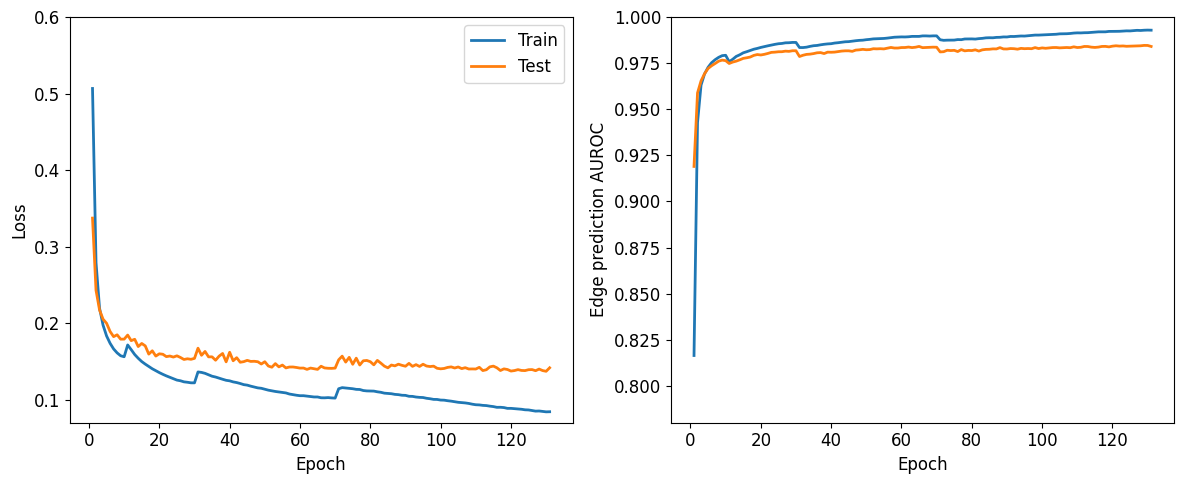

In [3]:
folder = f"{num_layer}layers_{hidden_dim}hdim{'_'+input_type if input_type != 'base' else ''}"
lw = 2
font_size = 12
plt.rcParams.update({'font.size': font_size})
with open(f'{ssl_trained_data_root}/{folder}/ssl_edge_training_log.json', 'r') as f:
	train_log = json.load(f)
with open(f'{ssl_trained_data_root}/{folder}/ssl_edge_config.json', 'r') as f:
	config = json.load(f)
best_epoch = config['best_epoch']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

epochs = range(1, len(train_log['train_loss'][:best_epoch]) + 1)

# Loss vs Epoch
axes[0].plot(epochs, train_log['train_loss'][:best_epoch], label='Train', linewidth=lw)
axes[0].plot(epochs, train_log['val_loss'][:best_epoch], label='Test', linewidth=lw)
axes[0].set_xlabel('Epoch', fontsize=font_size)
axes[0].set_ylabel('Loss', fontsize=font_size)
axes[0].set_ylim(0.07,0.6)
axes[0].legend()

# Edge AUROC vs Epoch
train_auroc = [m['edge_auc'] for m in train_log['train_metrics'][:best_epoch]]
val_auroc = [m['edge_auc'] for m in train_log['val_metrics'][:best_epoch]]
axes[1].plot(epochs, train_auroc, label='Train', linewidth=lw)
axes[1].plot(epochs, val_auroc, label='Test', linewidth=lw)
axes[1].set_xlabel('Epoch', fontsize=font_size)
axes[1].set_ylabel('Edge prediction AUROC', fontsize=font_size)
axes[1].set_ylim(0.78,1.0)


plt.tight_layout()
plt.savefig(f'Figures/{num_layer}_{hidden_dim}{'_'+input_type if input_type != "base" else ""}_training_curves.pdf', bbox_inches='tight', format='pdf')

## Compare selected model with other emb type model using the same hyperparameter

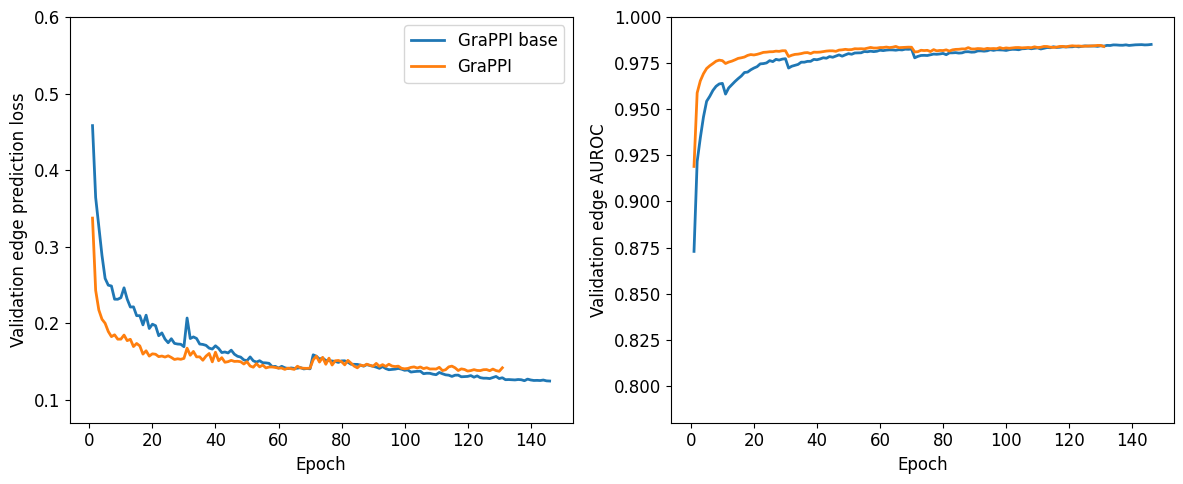

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lw = 2
font_size = 12
plt.rcParams.update({'font.size': font_size})
for input_type in ['base','esm']:
	folder = f"{num_layer}layers_{hidden_dim}hdim{'_'+input_type if input_type != 'base' else ''}"
	with open(f'{ssl_trained_data_root}/{folder}/ssl_edge_training_log.json', 'r') as f:
		train_log = json.load(f)
	with open(f'{ssl_trained_data_root}/{folder}/ssl_edge_config.json', 'r') as f:
		config = json.load(f)
	best_epoch = config['best_epoch']
	epochs = range(1, best_epoch + 1)

	axes[0].plot(epochs, train_log['val_loss'][:best_epoch], label='GraPPI '+input_type if input_type == 'base' else 'GraPPI', linewidth=lw)

	val_auroc = [m['edge_auc'] for m in train_log['val_metrics'][:best_epoch]]
	axes[1].plot(epochs, val_auroc, label='GraPPI '+input_type if input_type == 'base' else 'GraPPI', linewidth=lw)

axes[0].set_xlabel('Epoch', fontsize=font_size)
axes[0].set_ylabel('Validation edge prediction loss', fontsize=font_size)
axes[0].set_ylim(0.07,0.6)
axes[0].legend()

axes[1].set_xlabel('Epoch', fontsize=font_size)
axes[1].set_ylabel('Validation edge AUROC', fontsize=font_size)
axes[1].set_ylim(0.78,1.0)

plt.tight_layout()
plt.savefig(f'Figures/{num_layer}_{hidden_dim}_comparison.pdf', bbox_inches='tight', format='pdf')

# Downstream task plots

## Binder discrimination

### Ablation Study of Binder Cls

In [15]:
binder_cls_df = pd.read_csv('result_csv_data/binder_cls.csv')
binder_cls_df = binder_cls_df[(binder_cls_df['model']=='MLP')&(binder_cls_df['mean_unseen_auprc'].notnull())]
binder_cls_df

,input,encoder_num_module,encoder_hdim,model,test_auroc,test_f1,test_accuracy,mean_unseen_auprc,mean_unseen_auroc,unseen_auprc_std,unseen_auroc_std,PosFix_mean_auroc,PosFix_mean_auprc,PosFix_auprc_std,PosFix_auroc_std
24,base,1.0,512.0,MLP,0.883496,0.820420,0.807941,0.659598,0.888943,0.023228,0.006106,0.888933,0.880735,0.003782,0.003619
25,base,2.0,512.0,MLP,0.886932,0.802814,0.806431,0.661526,0.895802,0.013672,0.003131,0.891948,0.882593,0.004618,0.002974
26,base,3.0,512.0,MLP,0.886595,0.794900,0.802115,0.637094,0.884859,0.019267,0.008106,0.887027,0.874774,0.004785,0.004594
27,base,4.0,512.0,MLP,0.881701,0.819638,0.812905,0.656658,0.892543,0.025601,0.007705,0.889387,0.878663,0.007492,0.006716
28,base,5.0,512.0,MLP,0.870893,0.818593,0.809668,0.641276,0.885014,0.018193,0.007385,0.888252,0.879910,0.004136,0.002803
29,base,6.0,512.0,MLP,0.877140,0.807267,0.800820,0.659363,0.896090,0.014787,0.008031,0.893877,0.885900,0.002186,0.002424
30,base,1.0,1024.0,MLP,0.863954,0.798738,0.793483,0.663952,0.892586,0.023358,0.005467,0.889645,0.881686,0.001962,0.002945
31,base,2.0,1024.0,MLP,0.877590,0.793051,0.794346,0.667647,0.894355,0.009697,0.004738,0.895565,0.887706,0.003343,0.003614
32,base,3.0,1024.0,MLP,0.858700,0.762850,0.768019,0.627650,0.877312,0.027753,0.011265,0.883574,0.874653,0.005151,0.004456
33,base,4.0,1024.0,MLP,0.870317,0.791703,0.791972,0.643567,0.888333,0.026805,0.007378,0.885895,0.876298,0.004471,0.004296


In [16]:
def make_bar_label(row):
    input_name = str(row["input"]).strip().lower()
    num_module = int(row["encoder_num_module"]) if pd.notnull(row["encoder_num_module"]) else ""
    hdim = int(row["encoder_hdim"]) if pd.notnull(row["encoder_hdim"]) else ""

    if input_name == "base" and len(str(num_module)) > 0:
        return f"GraPPI_base_{num_module}_{hdim}"
    if input_name == "esm" and len(str(num_module)) > 0:
        return f"GraPPI_{num_module}_{hdim}"
    if input_name == "base" and len(str(num_module)) == 0:
        return f"Baseline_base"
    if input_name == "esm" and len(str(num_module)) == 0:
        return f"Baseline_esm"

#### Demo

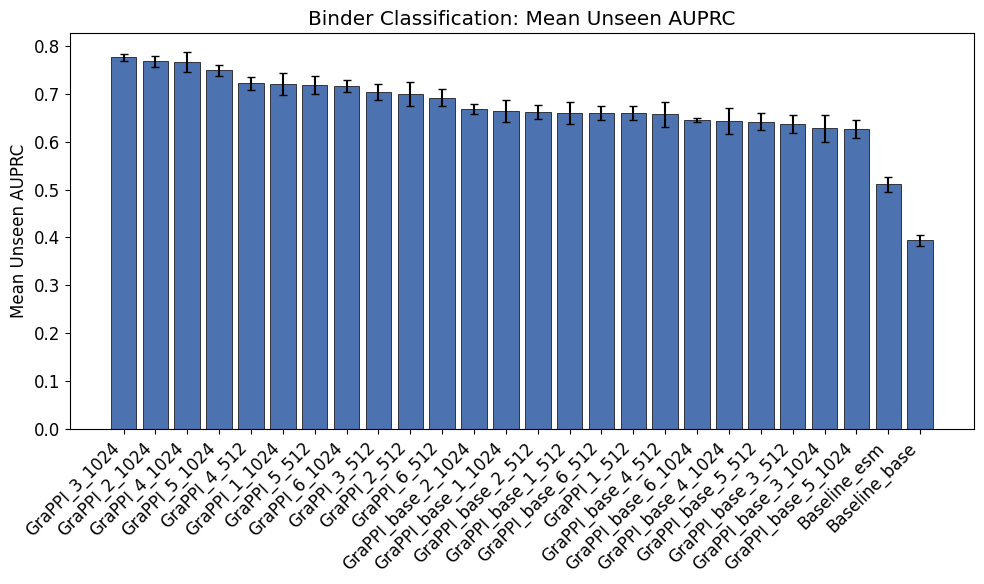

In [17]:
plot_df = binder_cls_df.copy()

plot_df["bar_label"] = plot_df.apply(make_bar_label, axis=1)

plot_df = plot_df.sort_values(
    by=["mean_unseen_auprc"],
    ascending=[False]
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(plot_df))
ax.bar(
    x,
    plot_df["mean_unseen_auprc"],
    yerr=plot_df["unseen_auprc_std"],
    capsize=3,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["bar_label"], rotation=45, ha="right")
ax.set_ylabel("Mean Unseen AUPRC")
ax.set_title("Binder Classification: Mean Unseen AUPRC")
ax.set_ylim(bottom=0)

plt.tight_layout()

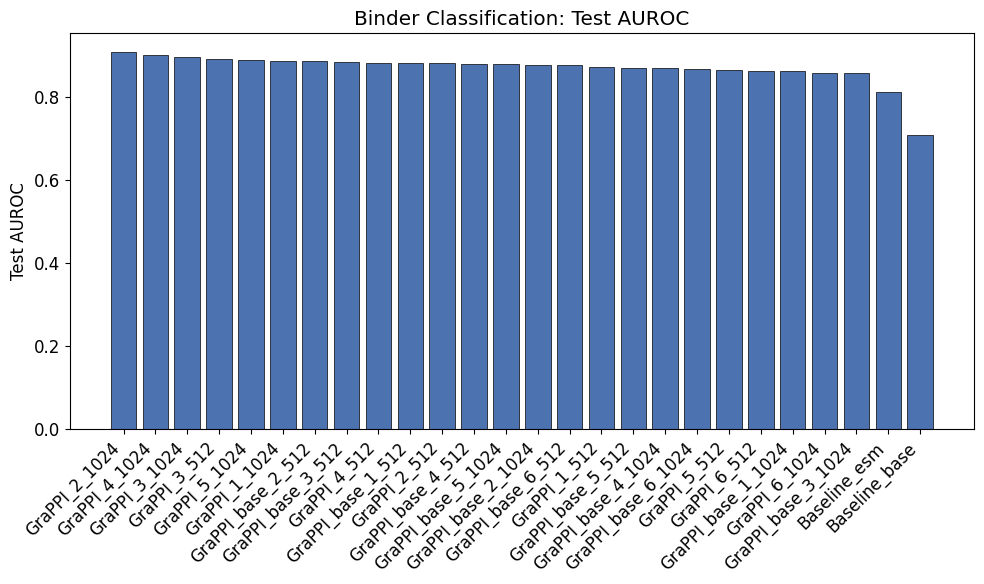

In [18]:
plot_df = binder_cls_df.copy()

plot_df["bar_label"] = plot_df.apply(make_bar_label, axis=1)

plot_df = plot_df.sort_values(
    by=["test_auroc"],
    ascending=[False]
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(plot_df))
ax.bar(
    x,
    plot_df["test_auroc"],
    capsize=3,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["bar_label"], rotation=45, ha="right")
ax.set_ylabel("Test AUROC")
ax.set_title("Binder Classification: Test AUROC")
ax.set_ylim(bottom=0)

plt.tight_layout()

#### Formal

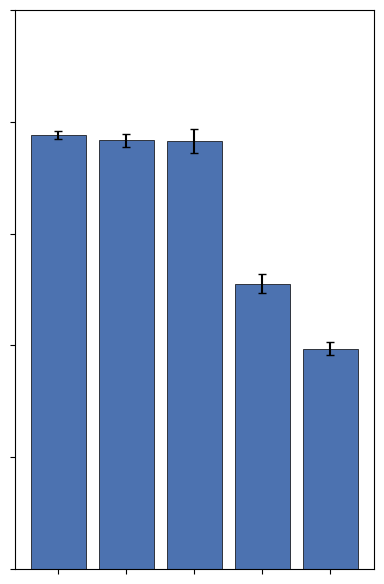

In [19]:
plot_df = binder_cls_df.copy()

plot_df["bar_label"] = plot_df.apply(make_bar_label, axis=1)

plot_df = plot_df.sort_values(
    by=["mean_unseen_auprc"],
    ascending=[False]
).reset_index(drop=True)
# use only top 3 and bottom 2
plot_df = pd.concat([plot_df.head(3), plot_df.tail(2)]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(4, 6))

x = np.arange(len(plot_df))
ax.bar(
    x,
    plot_df["mean_unseen_auprc"],
    yerr=plot_df["unseen_auprc_std"],
    capsize=3,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5
)

ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_yticklabels([])
#ax.set_ylabel("Mean Unseen AUPRC")
#ax.set_title("Binder Classification: Mean Unseen AUPRC")
ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig('Figures/binder_mean_unseen_auprc.pdf', bbox_inches='tight', format='pdf')

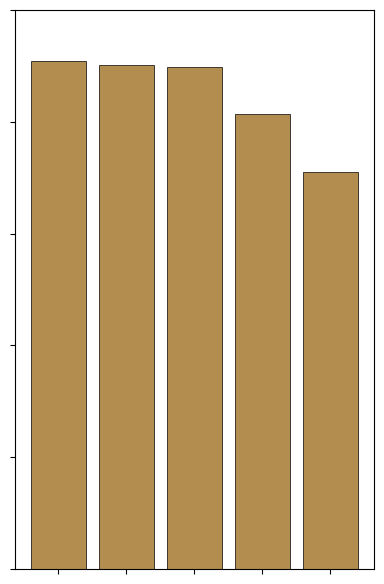

In [20]:
plot_df = binder_cls_df.copy()

plot_df["bar_label"] = plot_df.apply(make_bar_label, axis=1)

plot_df = plot_df.sort_values(
    by=["test_auroc"],
    ascending=[False]
).reset_index(drop=True)
# use only top 3 and bottom 2
plot_df = pd.concat([plot_df.head(3), plot_df.tail(2)]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(4, 6))

x = np.arange(len(plot_df))
ax.bar(
    x,
    plot_df["test_auroc"],
    capsize=3,
    color="#B38D4F",
    edgecolor="black",
    linewidth=0.5
)

ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig('Figures/binder_test_auroc.pdf', bbox_inches='tight', format='pdf')

### Subset performance in single case

In [ ]:
ssl_trained_data_root = '../GraPPI_data/trained_data_ssl_finetune'
hidden_dim = 10
num_layer = 2
input_type = 'only_base' #Recognised baseline prefixes: 'only_base', 'only_esm'
model = 'MLP' #'RandomForest' #'GradientBoosting' 'MLP' 'DecisionTree' 'SVR'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Directory that holds classifier_split_info.json (only needed in baseline mode)
split_info_dir = f'{ssl_trained_data_root}/{num_layer}layers_{hidden_dim}hdim_jkmean'

In [ ]:
# --- Config & paths ---
pdb_root_disc = '../GraPPI_data/curated_db'

IS_BASELINE = is_baseline_mode(input_type)

if IS_BASELINE:
    # ── Baseline mode: no pretrained encoder ──────────────────────────────
    # input_type = 'only_base' | 'only_esm' | 'only_esm480'
    baseline_dir, raw_emb_type, esm_dim = get_baseline_config(
        ssl_trained_data_root, input_type
    )
    # classifier_split_info.json is not saved in the baseline dir;
    # use split_info_dir (an encoder model dir that has it)
    test_graphs, test_labels, test_names, subset_indices = load_disc_binder_test_data(
        ssl_dir=split_info_dir, pdb_root=pdb_root_disc, embedding_type=raw_emb_type
    )
    print(f"Total test samples: {len(test_graphs)} "
          f"({int(test_labels.sum())} pos / {int((test_labels == 0).sum())} neg)")
    # No encoder embedding step — features come directly from raw graph nodes
    if model == 'MLP':
        disc_model = build_and_load_baseline_disc_classifier(baseline_dir, device)
    else:
        disc_model, _ = build_and_load_ml_baseline_disc_model(
            baseline_dir, model, input_type
        )

else:
    # ── Encoder-based mode ────────────────────────────────────────────────
    use_jk, jk_mode = True, 'mean'
    #if model == 'MLP':
    #    use_jk, jk_mode = True, 'mean'
    #else:

    ssl_dir, ft_dir, hidden_dim_val, file_emb_tag, esm_suffix = get_model_dirs(
        ssl_trained_data_root, num_layer, hidden_dim, input_type, use_jk, jk_mode
    )
    hgt_heads, dropout, message_style = load_ssl_encoder_config(ssl_dir)

    test_graphs, test_labels, test_names, subset_indices = load_disc_binder_test_data(
        ssl_dir, pdb_root_disc, input_type, ft_dir=ft_dir
    )
    print(f"Total test samples: {len(test_graphs)} "
          f"({int(test_labels.sum())} pos / {int((test_labels == 0).sum())} neg)")

    load_encoder_and_embed(
        ssl_dir, test_names, test_graphs, input_type, num_layer, hidden_dim_val,
        hgt_heads, message_style, device, use_jk, jk_mode,
    )
    print("Embeddings precomputed.")

    if model == 'MLP':
        pool_input_dim = get_pool_input_dim(
            hidden_dim_val, input_type, use_jk=use_jk, jk_mode=jk_mode, num_hgt_layers=num_layer
        )
        disc_model = build_and_load_disc_classifier(
            ft_dir, file_emb_tag, pool_input_dim, dropout, device,
            jk_suffix=f'_jk{jk_mode}',
        )
    else:
        jk_suffix = f'_jk{jk_mode}'
        disc_model, _ = build_and_load_ml_disc_model(ft_dir, model, jk_suffix)

    esm_dim = None  # not used in encoder mode

In [ ]:
# --- Inference ---
if model == 'MLP':
    if IS_BASELINE:
        y_prob = run_baseline_disc_mlp_inference(
            test_graphs, disc_model, device, esm_dim=esm_dim
        )
    else:
        y_prob = run_disc_binder_mlp_inference(test_graphs, disc_model, device)
else:
    if IS_BASELINE:
        y_prob = run_ml_baseline_disc_inference(test_graphs, disc_model, esm_dim=esm_dim)
    else:
        y_prob = run_ml_disc_binder_inference(test_graphs, disc_model)

cutoff = 0.5

subsets = [
    ('positive',     1),
    ('random_mut',   0),
    ('swapped_abag', 0),
    ('preppi',       0),
]

hdr = f"{'Subset':<16} {'N':>6} {'Recall':>8} {'Specificity':>12} {'Accuracy':>10} {'MeanProb':>9}"
print(hdr)
print('-' * len(hdr))
for subset_name, label in subsets:
    idx = np.array(subset_indices.get(subset_name, []))
    if len(idx) == 0:
        print(f"{subset_name:<16}  (no samples)")
        continue
    probs = y_prob[idx]
    recall      = (probs >= cutoff).mean()
    specificity = (probs < cutoff).mean()
    accuracy    = recall if label == 1 else specificity  # single-class subset
    recall_s      = f"{recall:>8.4f}"      if label == 1 else f"{'N/A':>8}"
    specificity_s = f"{specificity:>12.4f}" if label == 0 else f"{'N/A':>12}"
    print(f"{subset_name:<16} {len(idx):>6} {recall_s} {specificity_s} {accuracy:>10.4f} {probs.mean():>9.4f}")

### Subset performances in 4 models' comparison

In [21]:

# ============ Part 1: Model specs, paths, helper functions ============
ssl_trained_data_root = '../GraPPI_data/trained_data_ssl_finetune'
pdb_root_disc = '../GraPPI_data/curated_db'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Dir that holds classifier_split_info.json (only needed for baseline test loading)
split_info_dir = f'{ssl_trained_data_root}/2layers_10hdim_jkmean'

# The four models to compare (order = bar order within each subset group)
models_config = [
    {'label': 'GraPPI',        'is_baseline': False, 'input_type': 'esm',       'num_layer': 2, 'hidden_dim': 10, 'model': 'MLP'},
    {'label': 'GraPPI-base',   'is_baseline': False, 'input_type': 'base',      'num_layer': 2, 'hidden_dim': 9,  'model': 'MLP'},
    {'label': 'baseline-esm',  'is_baseline': True,  'input_type': 'only_esm',  'num_layer': 2, 'hidden_dim': 10, 'model': 'MLP'},
    {'label': 'baseline-base', 'is_baseline': True,  'input_type': 'only_base', 'num_layer': 2, 'hidden_dim': 10, 'model': 'MLP'},
]

# Subsets: (name, positive-class label)
subsets = [
    ('positive',     1),
    ('random_mut',   0),
    ('swapped_abag', 0),
    ('preppi',       0),
]
cutoff = 0.5


def load_model_and_data(cfg, device):
    """Load fresh test graphs + classifier for one model config.

    Returns: (test_graphs, subset_indices, disc_model, esm_dim, is_baseline)
    Note: graphs are reloaded per call because encoder embeddings are written
    into graph.x in place, so each model needs its own fresh copy.
    """
    is_baseline = cfg['is_baseline']
    model = cfg['model']

    if is_baseline:
        baseline_dir, raw_emb_type, esm_dim = get_baseline_config(
            ssl_trained_data_root, cfg['input_type']
        )
        test_graphs, test_labels, test_names, subset_indices = load_disc_binder_test_data(
            ssl_dir=split_info_dir, pdb_root=pdb_root_disc, embedding_type=raw_emb_type
        )
        if model == 'MLP':
            disc_model = build_and_load_baseline_disc_classifier(baseline_dir, device)
        else:
            disc_model, _ = build_and_load_ml_baseline_disc_model(
                baseline_dir, model, cfg['input_type']
            )
    else:
        use_jk, jk_mode = True, 'mean'
        ssl_dir, ft_dir, hidden_dim_val, file_emb_tag, esm_suffix = get_model_dirs(
            ssl_trained_data_root, cfg['num_layer'], cfg['hidden_dim'],
            cfg['input_type'], use_jk, jk_mode
        )
        hgt_heads, dropout, message_style = load_ssl_encoder_config(ssl_dir)
        test_graphs, test_labels, test_names, subset_indices = load_disc_binder_test_data(
            ssl_dir, pdb_root_disc, cfg['input_type'], ft_dir=ft_dir
        )
        load_encoder_and_embed(
            ssl_dir, test_names, test_graphs, cfg['input_type'], cfg['num_layer'],
            hidden_dim_val, hgt_heads, message_style, device, use_jk, jk_mode,
        )
        if model == 'MLP':
            pool_input_dim = get_pool_input_dim(
                hidden_dim_val, cfg['input_type'], use_jk=use_jk, jk_mode=jk_mode,
                num_hgt_layers=cfg['num_layer']
            )
            disc_model = build_and_load_disc_classifier(
                ft_dir, file_emb_tag, pool_input_dim, dropout, device,
                jk_suffix=f'_jk{jk_mode}',
            )
        else:
            disc_model, _ = build_and_load_ml_disc_model(ft_dir, model, f'_jk{jk_mode}')
        esm_dim = None

    return test_graphs, subset_indices, disc_model, esm_dim, is_baseline


def predict_probs(cfg, test_graphs, disc_model, esm_dim, is_baseline, device):
    """Run the right inference path for one model config."""
    model = cfg['model']
    if model == 'MLP':
        if is_baseline:
            return run_baseline_disc_mlp_inference(test_graphs, disc_model, device, esm_dim=esm_dim)
        return run_disc_binder_mlp_inference(test_graphs, disc_model, device)
    else:
        if is_baseline:
            return run_ml_baseline_disc_inference(test_graphs, disc_model, esm_dim=esm_dim)
        return run_ml_disc_binder_inference(test_graphs, disc_model)


def find_f1_max_cutoff(y_prob, y_true, n_thresholds=200):
    """Find the threshold in [0.01, 0.99] that maximises F1 score."""
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        pred = y_prob >= t
        tp = (pred & (y_true == 1)).sum()
        fp = (pred & (y_true == 0)).sum()
        fn = (~pred & (y_true == 1)).sum()
        denom = 2 * tp + fp + fn
        f1 = (2 * tp / denom) if denom > 0 else 0.0
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def subset_accuracies(y_prob, subset_indices, cutoff=0.5):
    """Per-subset accuracy: recall for positive, specificity for negatives."""
    accs = {}
    for subset_name, label in subsets:
        idx = np.array(subset_indices.get(subset_name, []))
        if len(idx) == 0:
            accs[subset_name] = np.nan
            continue
        probs = y_prob[idx]
        recall = (probs >= cutoff).mean()
        specificity = (probs < cutoff).mean()
        accs[subset_name] = recall if label == 1 else specificity
    return accs


In [22]:

# ============ Part 2: Load data/models, compute per-subset accuracies ============
results = {}           # label -> {subset_name: accuracy}
raw_probs = {}         # per-subset probability slices (for KDE plots)
raw_probs_full = {}    # full y_prob array per model (for cutoff search)
subset_indices_all = {}

# --- Pass 1: load every model and collect predictions ---
for cfg in models_config:
    print(f"\n=== {cfg['label']} (loading) ===")
    test_graphs, subset_indices, disc_model, esm_dim, is_baseline = load_model_and_data(cfg, device)
    y_prob = predict_probs(cfg, test_graphs, disc_model, esm_dim, is_baseline, device)
    raw_probs_full[cfg['label']] = y_prob
    subset_indices_all[cfg['label']] = subset_indices
    raw_probs[cfg['label']] = {
        sname: y_prob[np.array(subset_indices.get(sname, []))]
        for sname, _ in subsets
        if len(subset_indices.get(sname, [])) > 0
    }

# --- Find F1-optimal cutoff from baseline-base ---
bl_label = 'baseline-base'
bl_probs = raw_probs_full[bl_label]
bl_si    = subset_indices_all[bl_label]
# Reconstruct full y_true from subset membership
y_true_all = np.zeros(len(bl_probs))
for sname, label in subsets:
    idx = np.array(bl_si.get(sname, []))
    if len(idx):
        y_true_all[idx] = label
cutoff_f1, best_f1 = find_f1_max_cutoff(bl_probs, y_true_all)
print(f"\nBaseline-base F1-optimal cutoff: {cutoff_f1:.4f}  (F1={best_f1:.4f})")
print("(Applied uniformly to all models below)\n")

# --- Pass 2: compute per-subset accuracies with that cutoff ---
for cfg in models_config:
    label = cfg['label']
    accs = subset_accuracies(raw_probs_full[label], subset_indices_all[label], cutoff=cutoff_f1)
    results[label] = accs
    print(f"=== {label} ===")
    for sname, _ in subsets:
        n = len(subset_indices_all[label].get(sname, []))
        print(f"  {sname:<16} N={n:>5}  acc={accs[sname]:.4f}")



=== GraPPI (loading) ===
Using classifier split info from ft_dir: ../GraPPI_data/trained_data_ssl_finetune/2layers_10hdim_esm_jkmean/classifier_split_info.json
Positive test samples: 2317
Negative test samples (preppi): 1023
Negative test samples (random_mut): 1022
Negative test samples (swapped_abag): 272
Loaded encoder weights from ../GraPPI_data/trained_data_ssl_finetune/2layers_10hdim_esm/ssl_edge_best.pt
  Pre-trained at epoch 109 with loss 0.14651545614768297
  Encoder parameters loaded: 22,317,868 / 22,317,868 (100.0%)

Precomputing encoder embeddings for 4634 graphs... (JK mode=mean)


Encoding: 100%|██████████| 145/145 [00:09<00:00, 15.69it/s]


Precomputed embedding dims: receptor=1024, ligand=1024
Loaded disc binder classifier: ../GraPPI_data/trained_data_ssl_finetune/2layers_10hdim_esm_jkmean/disc_binder_jkmean_best.pt  (ft_hdim=256, n_cls_layers=2)

=== GraPPI-base (loading) ===
Using classifier split info from ft_dir: ../GraPPI_data/trained_data_ssl_finetune/2layers_9hdim_jkmean/classifier_split_info.json
Positive test samples: 2317
Negative test samples (preppi): 1023
Negative test samples (random_mut): 1022
Negative test samples (swapped_abag): 272
Loaded encoder weights from ../GraPPI_data/trained_data_ssl_finetune/2layers_9hdim/ssl_edge_best.pt
  Pre-trained at epoch 305 with loss 0.1712255174743718
  Encoder parameters loaded: 5,271,340 / 5,271,340 (100.0%)

Precomputing encoder embeddings for 4634 graphs... (JK mode=mean)


Encoding: 100%|██████████| 145/145 [00:05<00:00, 26.61it/s]


Precomputed embedding dims: receptor=512, ligand=512
Loaded disc binder classifier: ../GraPPI_data/trained_data_ssl_finetune/2layers_9hdim_jkmean/disc_binder_jkmean_best.pt  (ft_hdim=256, n_cls_layers=2)

=== baseline-esm (loading) ===
Using classifier split info from ssl_dir: ../GraPPI_data/trained_data_ssl_finetune/2layers_10hdim_jkmean/classifier_split_info.json
Positive test samples: 2317
Negative test samples (preppi): 1023
Negative test samples (random_mut): 1022
Negative test samples (swapped_abag): 272
Loaded baseline disc classifier: ../GraPPI_data/trained_data_ssl_finetune/esm_baseline/disc_binder_nn_best.pt  (node_in_dim=1280, hidden_dim=512, n_cls_layers=3)

=== baseline-base (loading) ===
Using classifier split info from ssl_dir: ../GraPPI_data/trained_data_ssl_finetune/2layers_10hdim_jkmean/classifier_split_info.json
Positive test samples: 2317
Negative test samples (preppi): 1023
Negative test samples (random_mut): 1022
Negative test samples (swapped_abag): 272
Loaded ba

#### Demo

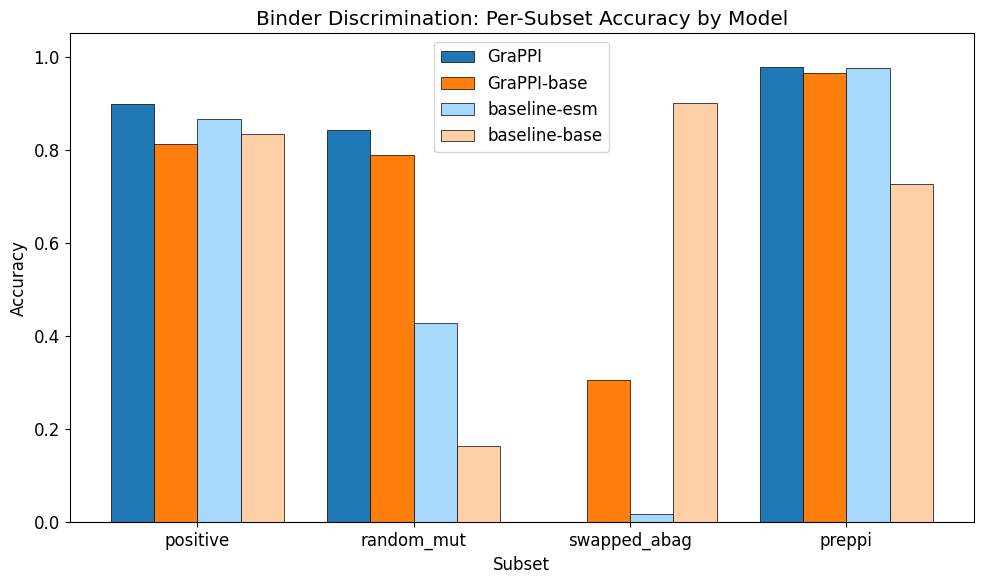

In [23]:
# ============ Part 3: Grouped bar plot (Accuracy by subset, 4 models) ============
model_labels = [cfg['label'] for cfg in models_config]
subset_names = [s[0] for s in subsets]

n_models = len(model_labels)
n_subsets = len(subset_names)
x = np.arange(n_subsets)
bar_width = 0.8 / n_models
colors = ['#1f77b4', "#ff7f0e", "#a7d9fd", "#ffd0a7"]

font_size = 12
plt.rcParams.update({'font.size': font_size})
fig, ax = plt.subplots(figsize=(10, 6))

for i, label in enumerate(model_labels):
    accs = [results[label][s] for s in subset_names]
    offset = (i - (n_models - 1) / 2) * bar_width
    ax.bar(x + offset, accs, bar_width, label=label,
           color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(subset_names)
ax.set_xlabel('Subset')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Binder Discrimination: Per-Subset Accuracy by Model')
ax.legend()
plt.tight_layout()

#### Formal

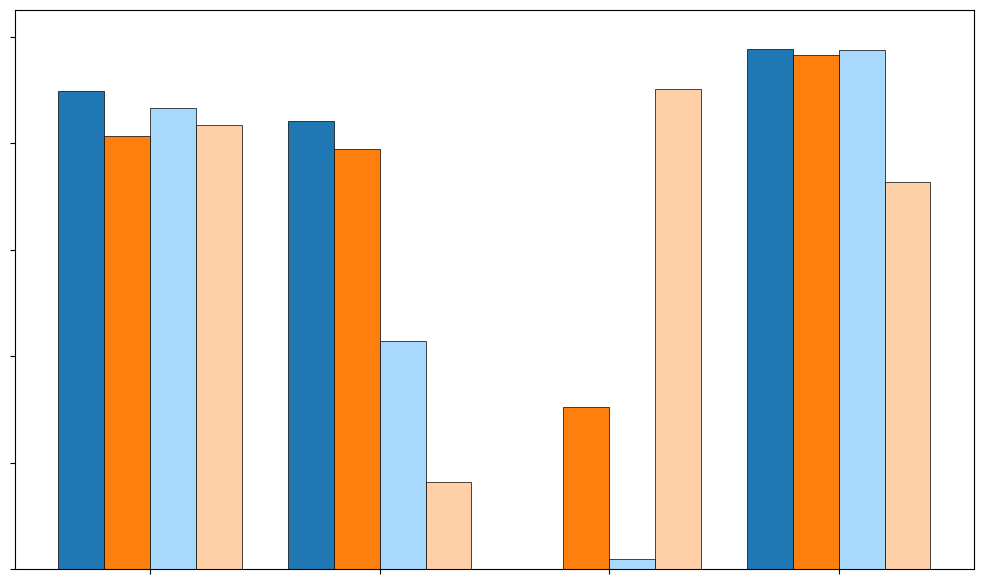

In [24]:
model_labels = [cfg['label'] for cfg in models_config]
subset_names = [s[0] for s in subsets]

n_models = len(model_labels)
n_subsets = len(subset_names)
x = np.arange(n_subsets)
bar_width = 0.8 / n_models
colors = ['#1f77b4', "#ff7f0e", "#a7d9fd", "#ffd0a7"]

font_size = 12
plt.rcParams.update({'font.size': font_size})
fig, ax = plt.subplots(figsize=(10, 6))

for i, label in enumerate(model_labels):
    accs = [results[label][s] for s in subset_names]
    offset = (i - (n_models - 1) / 2) * bar_width
    ax.bar(x + offset, accs, bar_width, label=label,
           color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_ylim(0, 1.05)
ax.set_yticklabels([])
plt.tight_layout()
plt.savefig('Figures/binder_subset_accuracy_4models.pdf', bbox_inches='tight', format='pdf')

#### Predicted Probability distribution

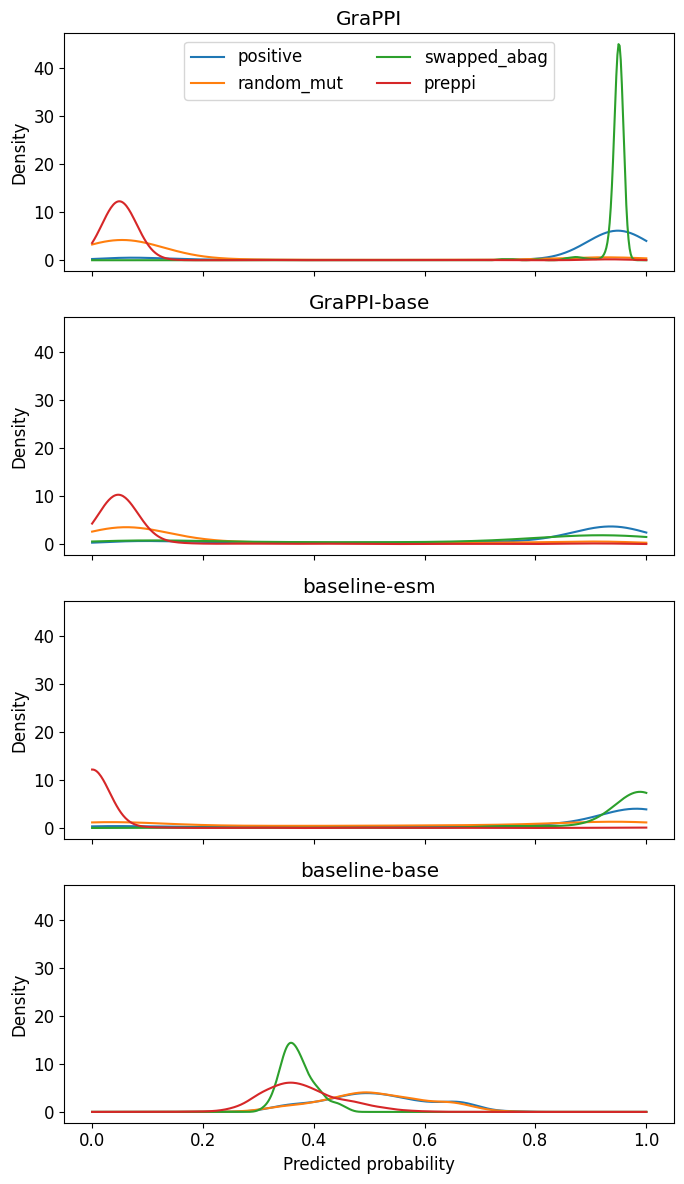

In [25]:
from scipy.stats import gaussian_kde

subset_colors = {
    'positive':     '#1f77b4',
    'random_mut':   '#ff7f0e',
    'swapped_abag': '#2ca02c',
    'preppi':       '#d62728',
}
x_grid = np.linspace(0, 1, 500)

fig, axes = plt.subplots(len(models_config), 1, figsize=(7, 3 * len(models_config)),
                         sharex=True, sharey=True)

for ax, cfg in zip(axes, models_config):
    label = cfg['label']
    for subset_name, _ in subsets:
        probs = raw_probs[label].get(subset_name)
        if probs is None or len(probs) == 0:
            continue
        kde = gaussian_kde(probs, bw_method='scott')
        ax.plot(x_grid, kde(x_grid), color=subset_colors[subset_name],
                linewidth=1.5, label=subset_name)
    ax.set_title(label)
    ax.set_ylabel('Density')

axes[0].legend(loc='upper center', ncol=2)
axes[-1].set_xlabel('Predicted probability')
plt.tight_layout()

## ∆G

### 5-fold CV

In [26]:
dg_df = pd.read_csv('result_csv_data/dG_pred.csv')
selected_df = dg_df[dg_df['model']=='SVR'].sort_values(by=['mean_val_rp'],ascending=False)
selected_df

,input,encoder_num_module,encoder_hdim,model,max_test_rp,max_val_rp,mean_val_rp,mean_test_rp,min_test_mae,mean_test_mae,test_rp_std,val_rp_std,test_mae_std
359,esm,6.0,1024.0,SVR,0.647848,0.682286,0.661312,0.614819,1.606829,1.633774,0.020590,0.013796,0.024161
339,esm,1.0,1024.0,SVR,0.625133,0.686489,0.660841,0.594462,1.592026,1.625933,0.018306,0.016932,0.025961
335,esm,6.0,512.0,SVR,0.684564,0.683083,0.658409,0.645467,1.572685,1.603639,0.021086,0.017045,0.019382
315,esm,1.0,512.0,SVR,0.644294,0.678605,0.656960,0.608149,1.569015,1.621481,0.018662,0.017433,0.029912
343,esm,2.0,1024.0,SVR,0.615809,0.688417,0.656170,0.595436,1.642880,1.662312,0.012739,0.020201,0.013742
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,base,5.0,64.0,SVR,0.592203,0.428356,0.356479,0.576331,1.833917,1.847335,0.009676,0.038969,0.010335
91,base,5.0,32.0,SVR,0.559832,0.428584,0.347510,0.554292,1.853728,1.859627,0.005885,0.058224,0.004503
95,base,6.0,32.0,SVR,0.554001,0.390808,0.338078,0.548520,1.868550,1.894054,0.006531,0.040775,0.013139
75,base,1.0,32.0,SVR,0.554972,0.372602,0.337693,0.548935,1.904636,1.920070,0.006665,0.025580,0.009488


### On test sets

In [27]:
ssl_trained_data_root = '../GraPPI_data/trained_data_ssl_finetune'
hidden_dim = 9
num_layer = 6
input_type = 'esm'
model = 'SVR' #'RandomForest' #'GradientBoosting' 'SVR' 'DecisionTree' 'MLP'
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [29]:
# --- Config & paths ---
pdb_root = '../GraPPI_data/curated_db'

IS_BASELINE = is_baseline_mode(input_type)

if IS_BASELINE:
    # Baseline mode: no pretrained encoder
    baseline_dir, raw_emb_type, esm_dim = get_baseline_config(
        ssl_trained_data_root, input_type
    )
    baseline_esm_suffix = '_esm' if raw_emb_type == 'esm' else ('_esm480' if raw_emb_type == 'esm480' else '')

    # --- Load test graphs ---
    s90_graphs = load_samples_from_dir(f'{pdb_root}/S90{baseline_esm_suffix}')
    s79_graphs = load_samples_from_dir(f'{pdb_root}/S79{baseline_esm_suffix}')
    print(f"Loaded S90: {len(s90_graphs)}, S79: {len(s79_graphs)}")

    # No encoder embedding step in baseline mode
    if model == 'MLP':
        dg_model, best_fold_num, stored_rp = build_and_load_baseline_dg_regressor(
            baseline_dir, input_type, device
        )
    else:
        dg_model, best_fold_num, stored_rp = build_and_load_ml_baseline_dg_model(
            baseline_dir, model, input_type
        )

else:
    # Encoder-based mode
    esm_dim = None  # not used in encoder mode

    use_jk, jk_mode = True, 'mean'

    ssl_dir, ft_dir, hidden_dim_val, file_emb_tag, esm_suffix = get_model_dirs(
        ssl_trained_data_root, num_layer, hidden_dim, input_type, use_jk, jk_mode
    )
    hgt_heads, dropout, message_style = load_ssl_encoder_config(ssl_dir)

    # --- Load test graphs ---
    s90_graphs = load_samples_from_dir(f'{pdb_root}/S90{esm_suffix}')
    s79_graphs = load_samples_from_dir(f'{pdb_root}/S79{esm_suffix}')
    print(f"Loaded S90: {len(s90_graphs)}, S79: {len(s79_graphs)}")

    # --- Precompute embeddings ---
    all_names = list(s90_graphs.keys()) + list(s79_graphs.keys())
    all_graphs = list(s90_graphs.values()) + list(s79_graphs.values())
    load_encoder_and_embed(
        ssl_dir, all_names, all_graphs, input_type, num_layer, hidden_dim_val,
        hgt_heads, message_style, device, use_jk, jk_mode,
    )
    print("Embeddings precomputed.")

    # --- Build & load model ---
    if model == 'MLP':
        best_fold_num, stored_rp, _ = load_best_fold(
            f'{ft_dir}/wt_dg{file_emb_tag}_jk{jk_mode}_5fold_summary.json'
        )
        print(f"Best fold: fold_{best_fold_num} (rp={stored_rp:.4f})")
        pool_input_dim = get_pool_input_dim(
            hidden_dim_val, input_type, use_jk=use_jk, jk_mode=jk_mode, num_hgt_layers=num_layer
        )
        dg_model = build_and_load_regressor(
            ft_dir, file_emb_tag, best_fold_num, pool_input_dim, dropout, device
        )
    else:
        jk_suffix = f'_jk{jk_mode}'
        dg_model, best_fold_num, stored_rp = build_and_load_ml_dg_model(ft_dir, model, jk_suffix)

Loaded S90: 90, S79: 79
Loaded encoder weights from ../GraPPI_data/trained_data_ssl_finetune/6layers_9hdim_esm/ssl_edge_best.pt
  Pre-trained at epoch 250 with loss 0.12856840766195593
  Encoder parameters loaded: 16,422,772 / 16,422,772 (100.0%)

Precomputing encoder embeddings for 169 graphs... (JK mode=mean)


Encoding: 100%|██████████| 6/6 [00:00<00:00, 15.55it/s]

Precomputed embedding dims: receptor=512, ligand=512
Embeddings precomputed.
Best ΔG fold for SVR: fold_1 (test rp=0.6846)
Loaded ML model: ../GraPPI_data/trained_data_ssl_finetune/6layers_9hdim_esm_jkmean/ml_dg_jkmean_fold_1_SVR.pkl



               S90       S79  Combined
      rp    0.6899    0.6842    0.6845
     MAE    1.4735    1.6859    1.5728


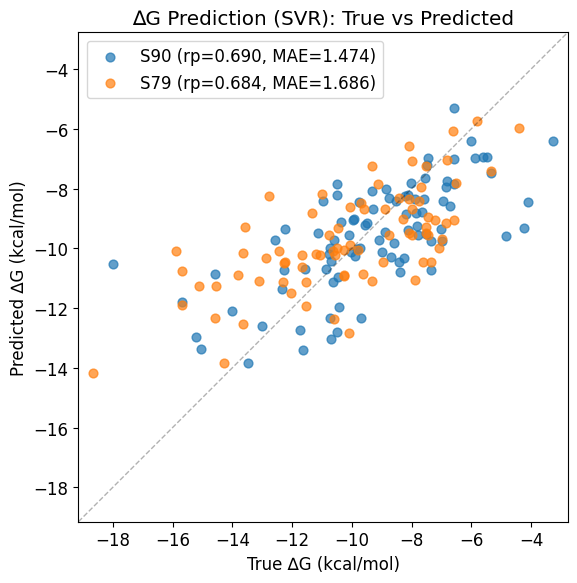

In [30]:
# --- Inference ---
if model == 'MLP':
    if IS_BASELINE:
        y_true_s90, y_pred_s90 = run_baseline_dg_mlp_inference(
            list(s90_graphs.values()), dg_model, device, esm_dim=esm_dim
        )
        y_true_s79, y_pred_s79 = run_baseline_dg_mlp_inference(
            list(s79_graphs.values()), dg_model, device, esm_dim=esm_dim
        )
    else:
        y_true_s90, y_pred_s90 = run_inference(list(s90_graphs.values()), dg_model, device)
        y_true_s79, y_pred_s79 = run_inference(list(s79_graphs.values()), dg_model, device)
else:
    if IS_BASELINE:
        y_true_s90, y_pred_s90 = run_ml_baseline_dg_inference(
            list(s90_graphs.values()), dg_model, esm_dim=esm_dim
        )
        y_true_s79, y_pred_s79 = run_ml_baseline_dg_inference(
            list(s79_graphs.values()), dg_model, esm_dim=esm_dim
        )
    else:
        y_true_s90, y_pred_s90 = run_ml_dg_inference(list(s90_graphs.values()), dg_model)
        y_true_s79, y_pred_s79 = run_ml_dg_inference(list(s79_graphs.values()), dg_model)

# --- Metrics ---
rp_s90, _ = pearsonr(y_true_s90, y_pred_s90)
rp_s79, _ = pearsonr(y_true_s79, y_pred_s79)
mae_s90 = np.mean(np.abs(y_true_s90 - y_pred_s90))
mae_s79 = np.mean(np.abs(y_true_s79 - y_pred_s79))
y_true_comb = np.concatenate([y_true_s90, y_true_s79])
y_pred_comb = np.concatenate([y_pred_s90, y_pred_s79])
rp_comb, _ = pearsonr(y_true_comb, y_pred_comb)
mae_comb = np.mean(np.abs(y_true_comb - y_pred_comb))

print(f"\n{'':>8}{'S90':>10}{'S79':>10}{'Combined':>10}")
print(f"{'rp':>8}{rp_s90:>10.4f}{rp_s79:>10.4f}{rp_comb:>10.4f}")
print(f"{'MAE':>8}{mae_s90:>10.4f}{mae_s79:>10.4f}{mae_comb:>10.4f}")

# --- Scatter plot ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(-y_true_s90, -y_pred_s90, alpha=0.7, s=40,
           label=f'S90 (rp={rp_s90:.3f}, MAE={mae_s90:.3f})')
ax.scatter(-y_true_s79, -y_pred_s79, alpha=0.7, s=40,
           label=f'S79 (rp={rp_s79:.3f}, MAE={mae_s79:.3f})')

all_vals = np.concatenate([-y_true_comb, -y_pred_comb])
lims = [all_vals.min() - 0.5, all_vals.max() + 0.5]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('True ∆G (kcal/mol)')
ax.set_ylabel('Predicted ∆G (kcal/mol)')
ax.set_title(f'∆G Prediction ({model}): True vs Predicted')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout()

## ∆∆G

In [31]:
ssl_trained_data_root = '../GraPPI_data/trained_data_ssl_finetune'
hidden_dim = 10
num_layer = 2
input_type = 'esm'
model = 'SVR' #RandomForest GradientBoosting DecisionTree SVR

In [32]:
# --- Config & paths ---
pdb_root_ddg = '../GraPPI_data/curated_db'

use_jk, jk_mode = True, 'mean'

ssl_dir, ft_dir, hidden_dim_val, file_emb_tag, _ = get_model_dirs(
    ssl_trained_data_root, num_layer, hidden_dim, input_type, use_jk, jk_mode, if_estra_path=False
)
hgt_heads, dropout, message_style = load_ssl_encoder_config(ssl_dir)

# The ML model was fitted on GPU-computed embeddings; use CUDA here to reproduce
# the exact same floating-point feature values as during training.
embed_device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# --- Load test pairs ---
(mut_names, mut_graphs, wt_graphs,
 y_true_mut_aff, y_true_wt_aff, y_true_ddg,
 unique_wt_names, unique_wt_graphs) = load_ddg_test_pairs(pdb_root_ddg, input_type)

# --- Precompute embeddings ---
load_encoder_and_embed(
    ssl_dir, mut_names, mut_graphs, input_type, num_layer, hidden_dim_val,
    hgt_heads, message_style, embed_device, use_jk, jk_mode,
)
print(f"Precomputing WT embeddings ({len(unique_wt_graphs)} unique)...")
load_encoder_and_embed(
    ssl_dir, unique_wt_names, unique_wt_graphs, input_type, num_layer, hidden_dim_val,
    hgt_heads, message_style, embed_device, use_jk, jk_mode,
)
print("Embeddings precomputed.")

# --- Build & load ΔΔG model ---
if model == 'MLP':
    ddg_sum_path = f'{ft_dir}/ddg_5fold_jk{jk_mode}_summary.json'
    best_fold_num_ddg, stored_rp_ddg, ddg_summary = load_best_fold(ddg_sum_path)
    ddg_input_mode = ddg_summary.get('ddg_input_mode', 'concat_diff')
    print(f"Best fold: fold_{best_fold_num_ddg} (rp={stored_rp_ddg:.4f}), input_mode={ddg_input_mode}")

    pool_input_dim_ddg = get_pool_input_dim(
        hidden_dim_val, input_type, use_jk=use_jk, jk_mode=jk_mode, num_hgt_layers=num_layer
    )
    ddg_model = build_and_load_ddg_regressor(
        ft_dir, best_fold_num_ddg, ddg_input_mode, pool_input_dim_ddg, dropout, embed_device
    )
else:
    jk_suffix = f'_jk{jk_mode}'
    ddg_model, best_fold_num_ddg, stored_rp_ddg = build_and_load_ml_ddg_model(ft_dir, model, jk_suffix)


After filtering: 140 mutants, 26 wild-types
Matched pairs: 140
Loaded encoder weights from ../GraPPI_data/trained_data_ssl_finetune/2layers_10hdim_esm/ssl_edge_best.pt
  Pre-trained at epoch 109 with loss 0.14651545614768297
  Encoder parameters loaded: 22,317,868 / 22,317,868 (100.0%)

Precomputing encoder embeddings for 140 graphs... (JK mode=mean)


Encoding: 100%|██████████| 5/5 [00:00<00:00, 19.43it/s]


Precomputed embedding dims: receptor=1024, ligand=1024
Precomputing WT embeddings (16 unique)...
Loaded encoder weights from ../GraPPI_data/trained_data_ssl_finetune/2layers_10hdim_esm/ssl_edge_best.pt
  Pre-trained at epoch 109 with loss 0.14651545614768297
  Encoder parameters loaded: 22,317,868 / 22,317,868 (100.0%)

Precomputing encoder embeddings for 16 graphs... (JK mode=mean)


Encoding: 100%|██████████| 1/1 [00:00<00:00, 32.65it/s]

Precomputed embedding dims: receptor=1024, ligand=1024
Embeddings precomputed.
Best ΔΔG fold for SVR: fold_5 (test rp=0.8377)
Loaded ML model: ../GraPPI_data/trained_data_ssl_finetune/2layers_10hdim_esm_jkmean/ml_ddg_jkmean_fold_5_SVR.pkl



Stored fold_test_rp:   0.8377
rp (mut aff):           0.8377   MAE: 1.1980
rp (ΔΔG):               0.4649   MAE: 1.1980


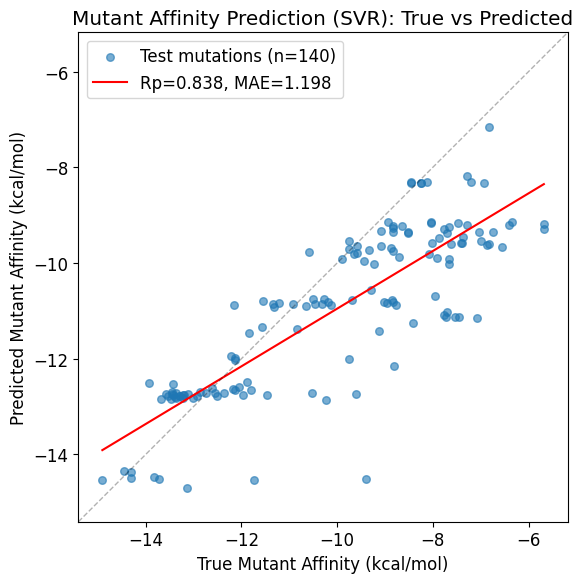

In [33]:
# --- Inference ---
# Both MLP and ML models predict mutant affinity (see extract_features_ddg)
# ΔΔG = wt_aff − pred_mut_aff in both cases
if model == 'MLP':
    y_pred_mut_aff = run_ddg_inference(mut_graphs, wt_graphs, ddg_model, embed_device)
else:
    y_pred_mut_aff = run_ml_ddg_inference(mut_graphs, wt_graphs, ddg_model)
y_pred_ddg = y_true_wt_aff - y_pred_mut_aff

# --- Metrics ---
rp_mut_aff, _ = pearsonr(y_true_mut_aff, y_pred_mut_aff)
mae_mut_aff    = np.mean(np.abs(y_true_mut_aff - y_pred_mut_aff))
rp_ddg,     _  = pearsonr(y_true_ddg, y_pred_ddg)
mae_ddg        = np.mean(np.abs(y_true_ddg - y_pred_ddg))

print(f"\nStored fold_test_rp:   {stored_rp_ddg:.4f}")
print(f"rp (mut aff):           {rp_mut_aff:.4f}   MAE: {mae_mut_aff:.4f}")
print(f"rp (ΔΔG):               {rp_ddg:.4f}   MAE: {mae_ddg:.4f}")

# --- Scatter plot: mutant affinity ---
slope, intercept, *_ = linregress(-y_true_mut_aff, -y_pred_mut_aff)
x_fit = np.linspace(-y_true_mut_aff.min(), -y_true_mut_aff.max(), 100)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(-y_true_mut_aff, -y_pred_mut_aff, alpha=0.6, s=30,
           label=f'Test mutations (n={len(y_true_mut_aff)})')
ax.plot(x_fit, slope * x_fit + intercept, 'r-', linewidth=1.5,
        label=f'Rp={rp_mut_aff:.3f}, MAE={mae_mut_aff:.3f}')

all_vals = np.concatenate([-y_true_mut_aff, -y_pred_mut_aff])
lims = [all_vals.min() - 0.5, all_vals.max() + 0.5]
ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=1)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('True Mutant Affinity (kcal/mol)')
ax.set_ylabel('Predicted Mutant Affinity (kcal/mol)')
ax.set_title(f'Mutant Affinity Prediction ({model}): True vs Predicted')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout()
